# Unemployment Analysis with Python

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on unemployment data in India to identify regional and temporal trends, with a special focus on the impact of the COVID-19 pandemic on unemployment rates.

## Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## Load Dataset

In [2]:
df = pd.read_csv("Unemployment in India.csv")

## Dataset Overview

In [3]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [4]:
df.shape

(768, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    str    
 1    Date                                     740 non-null    str    
 2    Frequency                                740 non-null    str    
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB


In [6]:
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

## Data Cleaning

In [7]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

KeyError: 'Date'

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='str')

In [10]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    str           
 1   Date                                     740 non-null    datetime64[us]
 2   Frequency                                740 non-null    str           
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    str           
dtypes: datetime64[us](1), float64(3), str(3)
memory usage: 42.1 KB


## Data Exploration

In [12]:
region_avg = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

region_avg

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64

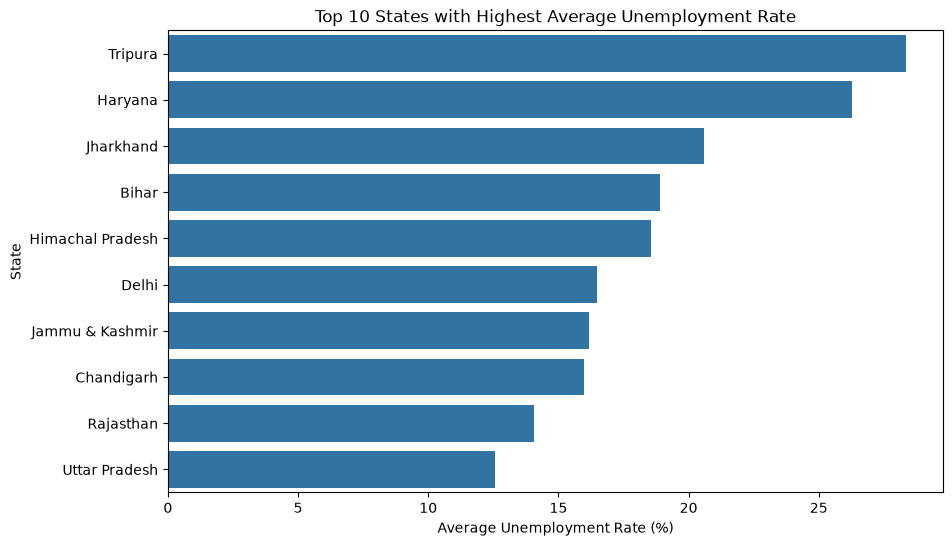

In [13]:
top10 = region_avg.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values, y=top10.index)

plt.title("Top 10 States with Highest Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

### Observation

The bar chart shows the top 10 states with the highest average unemployment rate. These regions experienced consistently higher unemployment compared to other states during the recorded period.

## Month-wise Unemployment Trend

In [14]:
df["Month"] = df["Date"].dt.month_name()

In [15]:
month_avg = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()
month_avg

Month
April        23.641569
August        9.637925
December      9.497358
February      9.964717
January       9.950755
July          9.033889
June         10.553462
March        10.700577
May          16.646190
November      9.868364
October       9.900909
September     9.051731
Name: Estimated Unemployment Rate (%), dtype: float64

In [16]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

month_avg = month_avg.reindex(month_order)

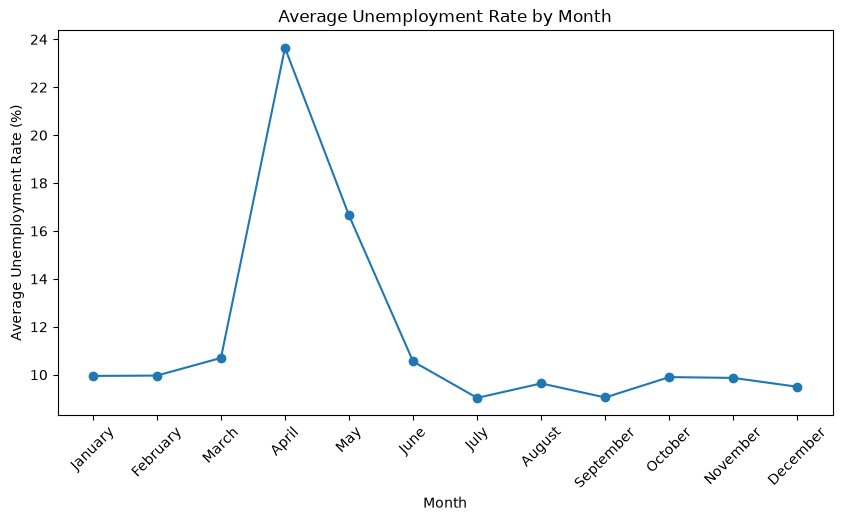

In [17]:
plt.figure(figsize=(10,5))

plt.plot(month_avg.index, month_avg.values, marker="o")

plt.title("Average Unemployment Rate by Month")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Observation

The line chart shows how the average unemployment rate changed across different months. A noticeable rise in unemployment can be observed during the COVID-19 period, indicating the impact of nationwide lockdowns and reduced economic activity.

## Time-Series Analysis of Major States

In [18]:
df["Region"].unique()

<StringArray>
[  'Andhra Pradesh',            'Assam',            'Bihar',
     'Chhattisgarh',            'Delhi',              'Goa',
          'Gujarat',          'Haryana', 'Himachal Pradesh',
  'Jammu & Kashmir',        'Jharkhand',        'Karnataka',
           'Kerala',   'Madhya Pradesh',      'Maharashtra',
        'Meghalaya',           'Odisha',       'Puducherry',
           'Punjab',        'Rajasthan',           'Sikkim',
       'Tamil Nadu',        'Telangana',          'Tripura',
    'Uttar Pradesh',      'Uttarakhand',      'West Bengal',
                nan,       'Chandigarh']
Length: 29, dtype: str

In [19]:
states = ["Maharashtra", "Tamil Nadu", "Karnataka"]

state_data = df[df["Region"].isin(states)]

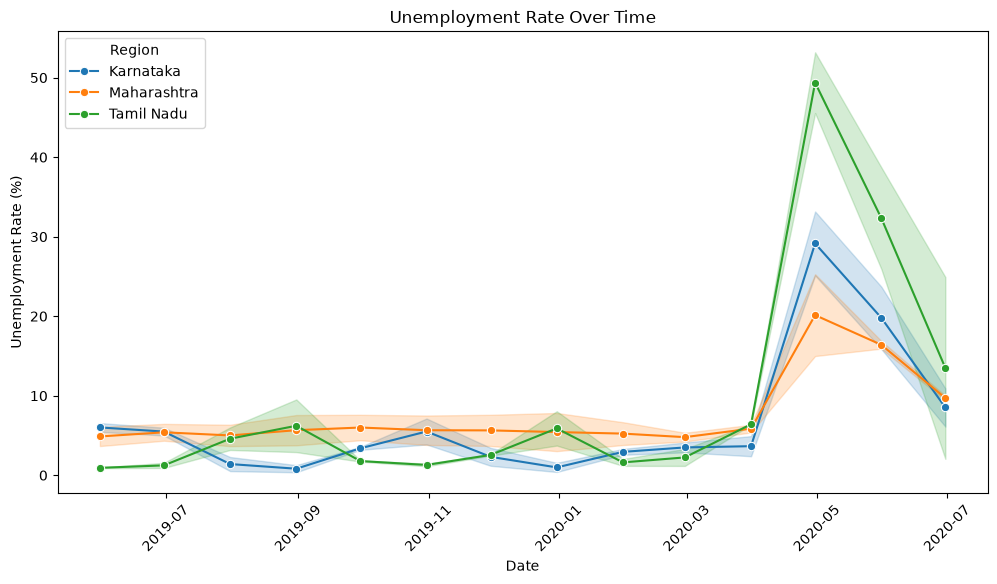

In [20]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=state_data,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

### Observation

The line chart compares unemployment trends over time for Maharashtra, Tamil Nadu, and Karnataka. A sharp increase in unemployment can be observed during the COVID-19 lockdown period, followed by gradual recovery. The impact varied across states, indicating differences in economic activities and recovery rates.

## Correlation Heatmap

In [21]:
correlation = df[
    [
        "Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"
    ]
].corr()

correlation

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


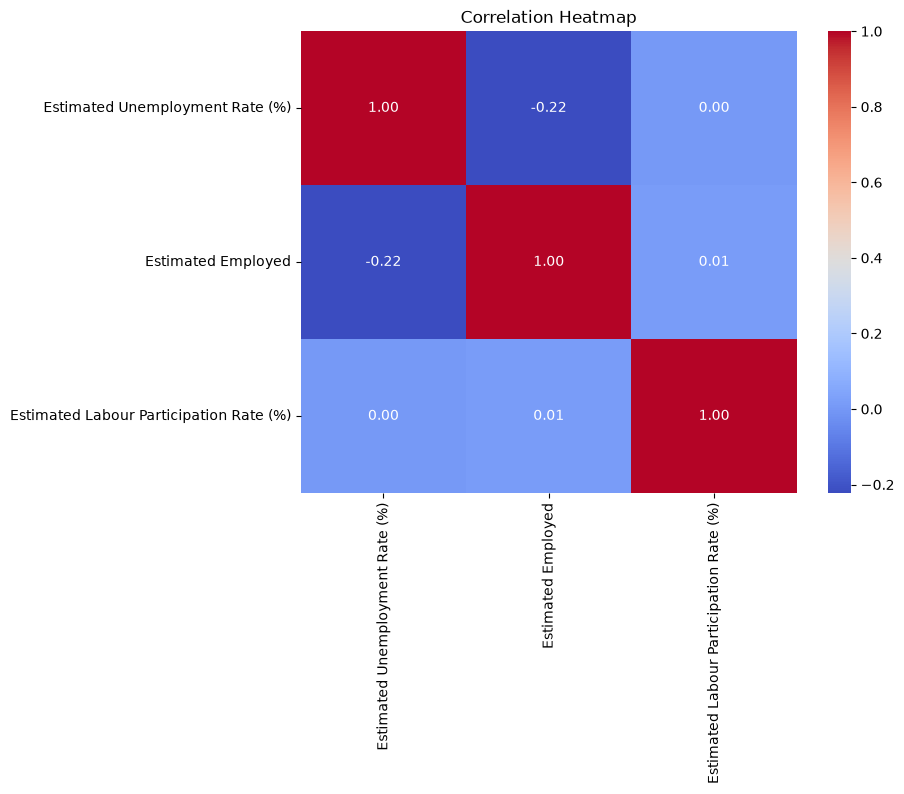

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the correlation between unemployment rate, employment, and labour participation rate. Positive correlation indicates that two variables increase together, while negative correlation indicates that one variable increases as the other decreases. This helps understand the relationship between different employment indicators.

## Pre-COVID vs Post-COVID Analysis

In [24]:
pre_covid = df[df["Date"] < "2020-03-01"]

post_covid = df[df["Date"] >= "2020-03-01"]

In [25]:
pre_avg = pre_covid["Estimated Unemployment Rate (%)"].mean()
post_avg = post_covid["Estimated Unemployment Rate (%)"].mean()

print("Average Unemployment Rate Before COVID:", round(pre_avg, 2))
print("Average Unemployment Rate After COVID :", round(post_avg, 2))

Average Unemployment Rate Before COVID: 9.51
Average Unemployment Rate After COVID : 17.77


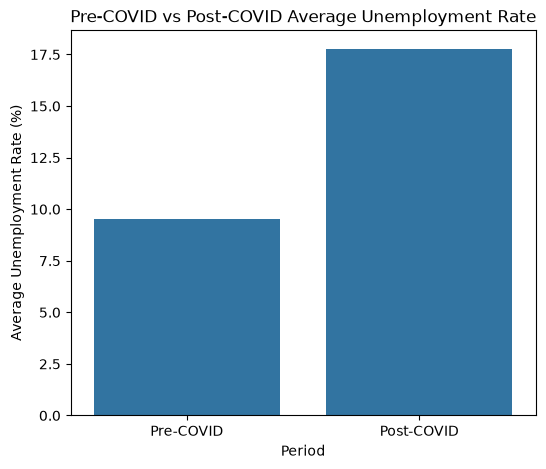

In [26]:
comparison = pd.DataFrame({
    "Period": ["Pre-COVID", "Post-COVID"],
    "Average Unemployment Rate": [pre_avg, post_avg]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate"
)

plt.title("Pre-COVID vs Post-COVID Average Unemployment Rate")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

### Observation

The comparison shows that the average unemployment rate increased after the COVID-19 outbreak. This indicates the significant impact of lockdowns and reduced economic activities on employment across India.

# Conclusion

This project analyzed unemployment trends in India using Exploratory Data Analysis (EDA). The analysis showed regional differences in unemployment rates, monthly variations, and the impact of the COVID-19 pandemic. Visualizations such as bar charts, line charts, and heatmaps helped identify important trends and relationships among unemployment, employment, and labour participation rates. Overall, the project demonstrates how data visualization can provide meaningful insights into economic conditions.